### Импорт библиотек

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Часть 2: Классификация ирисов Фишера с помощью дерева решений

### Загрузка данных

In [97]:
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

### Преобразование данных

In [98]:
df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species_name'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df['species'] = iris.target
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_name,species
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


### Описание данных

In [99]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [100]:
print(f'Null values: {df.isnull().sum()}')

Null values: sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species_name    0
species         0
dtype: int64


In [101]:
print(f'values counts: {df["species"].value_counts()}')

values counts: species
0    50
1    50
2    50
Name: count, dtype: int64


### Визуализация данных

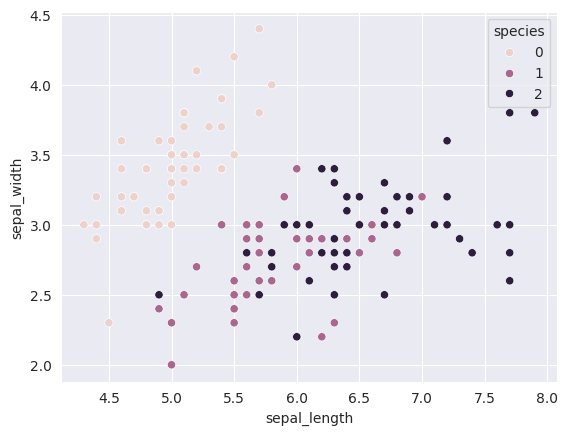

In [102]:
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.show()

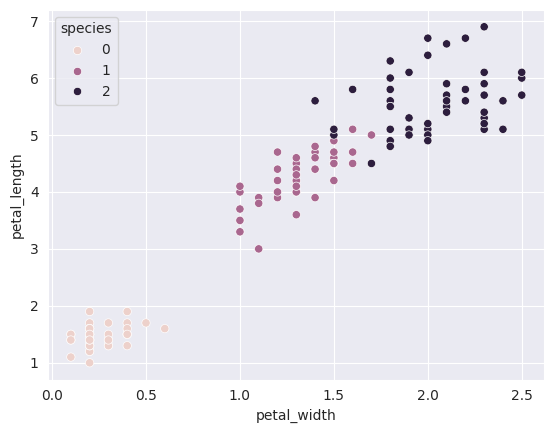

In [103]:
sns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species')
plt.show()

### Создание массивов X и y входных данных и меток классов

In [104]:
X = iris.data
y = iris.target

### Разбиение выборки

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Обучение `overfitted` `DecisionTreeClassifier`

In [106]:
overfitted_tree = DecisionTreeClassifier(max_depth=100, random_state=2025)
overfitted_tree.fit(X_train, y_train)
predictions = overfitted_tree.predict(X_test)

print(f'Overfitted tree Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

Overfitted tree Accuracy: 0.93


### Визуализация `overfitted` `DecisionTreeClassifier`

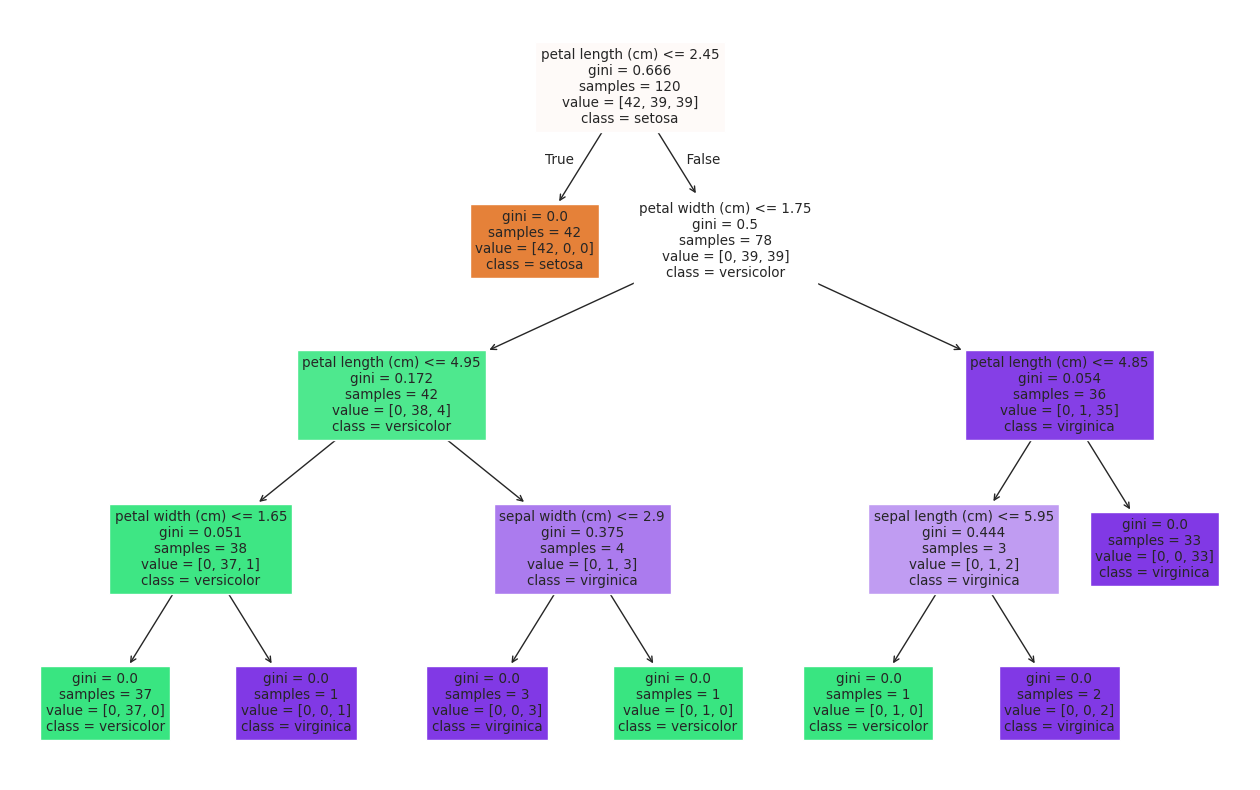

In [107]:
plt.figure(figsize=(16, 10))
plot_tree(overfitted_tree, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

### Обучение `pruned` `DecisionTreeClassifier`

In [108]:
tree = DecisionTreeClassifier(max_depth=3, random_state=2025, min_samples_leaf=4)
tree.fit(X_train, y_train)
predictions = tree.predict(X_test)
print(f'Pruned tree Accuracy: {np.sum(y_test == predictions) / len(y_test):.3f}')

Pruned tree Accuracy: 0.967


### Визуализация `pruned` `DecisionTreeClassifier`

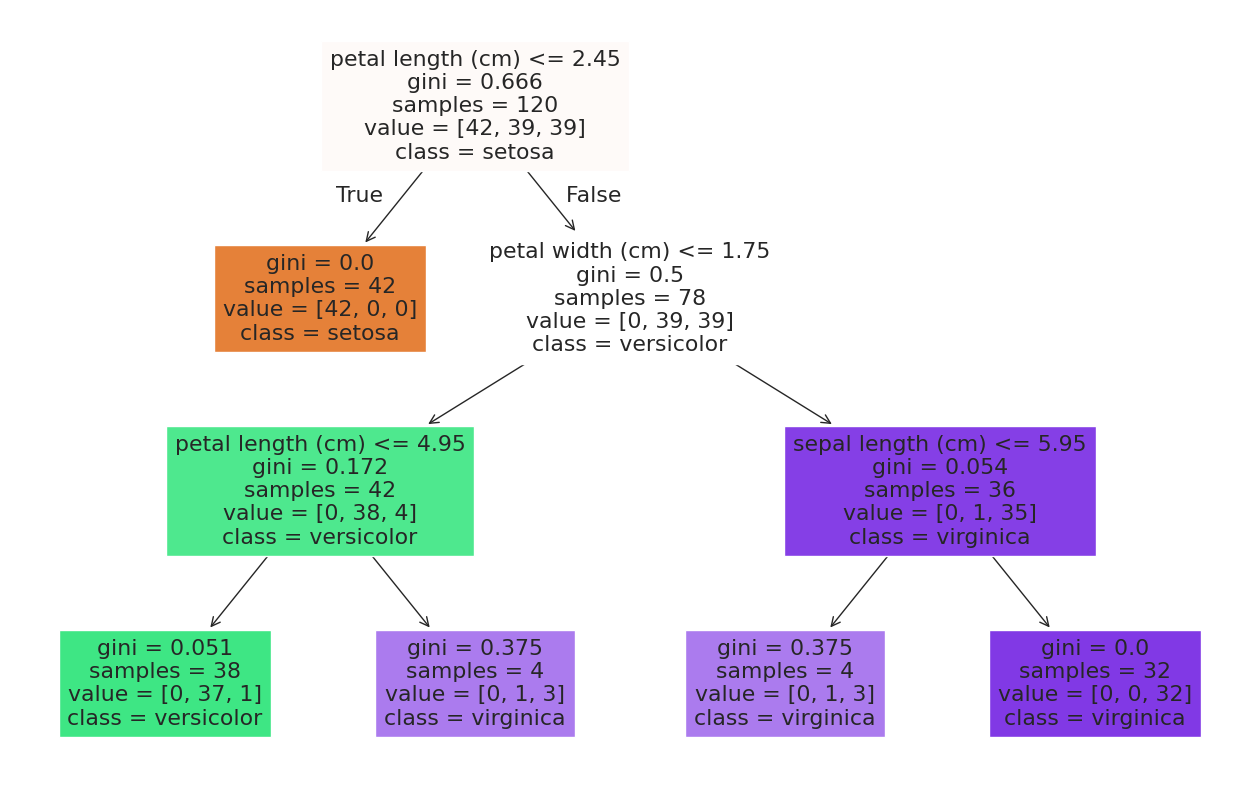

In [109]:
plt.figure(figsize=(16, 10))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

### Обучение `RandomForestClassifier`

In [110]:
rf = RandomForestClassifier(random_state=2025)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
print(f'Random Forest Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

Random Forest Accuracy: 0.97


### Визуализация `RandomForestClassifier`

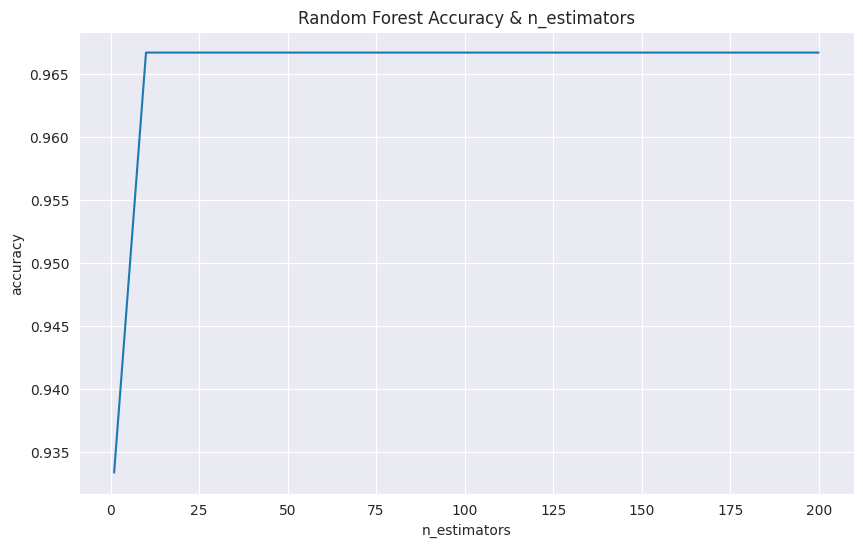

In [111]:
n_estimators = [1, 10, 20, 50, 100, 200]
rf_accuracies = list()
for n in n_estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=2025)
    rf.fit(X_train, y_train)
    predictions = rf.predict(X_test)
    rf_accuracies.append(np.sum(y_test == predictions) / len(y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators, rf_accuracies)
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.title('Random Forest Accuracy & n_estimators')
plt.grid(True)
plt.show()

### Обучение `RandomForestClassifier` с дополнительными параметрами

In [112]:
rf_with_params = RandomForestClassifier(n_estimators=100, max_depth=3, max_features=2,  random_state=2025)
rf_with_params.fit(X_train, y_train)
predictions = rf_with_params.predict(X_test)
print(f'RF with params Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

RF with params Accuracy: 0.97


### Обучение `GradientBoostingClassifier`

In [113]:
gb = GradientBoostingClassifier(random_state=2025)
gb.fit(X_train, y_train)
predictions = gb.predict(X_test)
print(f'Gradient Boosting Accuracy: {np.sum(y_test == predictions) / len(y_test):.2f}')

Gradient Boosting Accuracy: 0.97


### Визуализация `GradientBoostingClassifier`

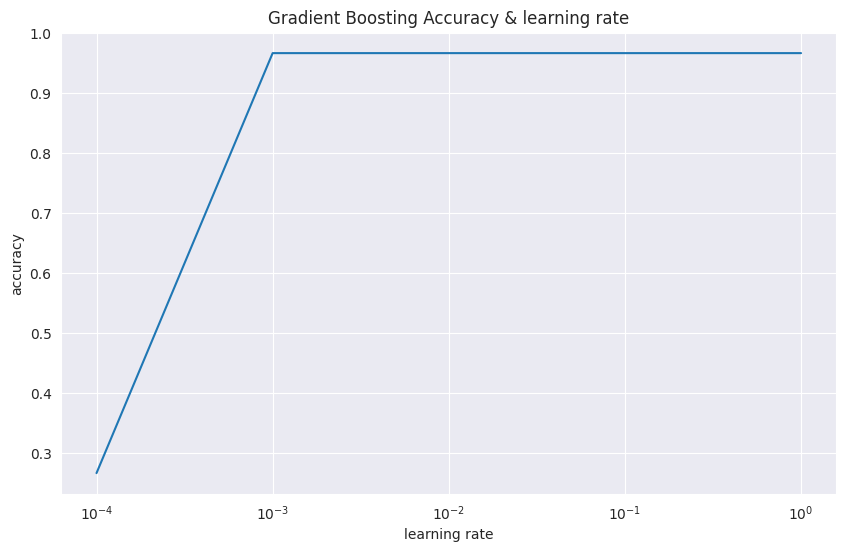

In [114]:
learning_rates = [0.0001, 0.001, 0.01, 0.5, 1]
gb_accuracies = list()
for l in learning_rates:
    gb = GradientBoostingClassifier(learning_rate=l, random_state=2025)
    gb.fit(X_train, y_train)
    predictions = gb.predict(X_test)
    gb_accuracies.append(np.sum(y_test == predictions) / len(y_test))

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, gb_accuracies)
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('accuracy')
plt.title('Gradient Boosting Accuracy & learning rate')
plt.grid(True)
plt.show()